In [1197]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1198]:
#Importation des librairies
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import chi2_contingency, pearsonr, spearmanr, kendalltau, f_oneway, kruskal
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from pandas.plotting import scatter_matrix
from sklearn.cluster import KMeans

In [1199]:


#Importation du Dispo alimentaire .csv
df_dispo_alimentaire = pd.read_csv("DisponibiliteAlimentaire_2017.csv", sep=',')

#Importation du fichier population.csv
df_population_initiale = pd.read_csv("Population_2000_2018.csv", sep=',')

#Importation du fichier infos_global.csv
df_infos_global = pd.read_csv("infos_global.csv", sep=',')



In [1200]:
#PESTEL => pour choix des variables en vue d'une étude de marché

#Politique : Stabilité politique et absence de violence/terrorisme (indice)
#Economique : PIB
#Social : population (ok pas de vide)
#Techno :
#Ecologique : dispo alimentaire en volailles, importation de volailles et part de dispo intérieure de volailles sur dispo intérieur totale de nourriture (sum tout produit)
#Legal :

#Dispo alimentaire -> Dispo produit (colonne element dispo interieur ou quantité + colonne produit viande volailes): tableau avec tous les pays qui montre la dispo de volaile dans chaque pays / la somme des dispo alimentaire de tous les produits par pays (CALCUL DE LA PART DE DISPO DE VOLAILLES PAR RAPPORT A LA DISPO DE NOURRITURE GENERAL)
#Dispo alimentaire -> Importation de ce produit : colonne lignes importation

In [1201]:
#--------------------------- ON PART DE LA BASE data set Population ----------------------------------
#Nettoyage population pour garder les valeurs pour la jointure et pour la population dans chaque pays pour 2017 pour coller au df dispo_alimentaire
#PARAMETRAGE + CLEANING VARIABLES DE BASE

df_population_initiale = df_population_initiale[["Zone", "Année", "Valeur"]]
df_population_initiale = df_population_initiale[df_population_initiale["Année"] == 2017]

df_population_initiale["Zone"] = df_population_initiale["Zone"].astype(str)
df_population_initiale["Année"] = df_population_initiale["Année"].astype(int)
df_population_initiale["Valeur"] = df_population_initiale["Valeur"].astype(int)

#Valeur -> Population divisée par 1000
df_population_initiale.rename(columns={"Valeur": "Population / 1000"}, inplace=True)

df_population_initiale.info()




<class 'pandas.core.frame.DataFrame'>
Index: 236 entries, 17 to 4409
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Zone               236 non-null    object
 1   Année              236 non-null    int64 
 2   Population / 1000  236 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 7.4+ KB


In [1202]:
#------------------------- AJOUT DATA SET DISPO ALIMENTAIRE SIMPLIFIÉ -------------------------

#PARAMETRAGE Volaille
df_volaille = df_dispo_alimentaire[df_dispo_alimentaire["Produit"] == "Viande de Volailles"]

cols_map = {
    "Disponibilité alimentaire en quantité (kg/personne/an)": "dispo_Volailles_kg_personne_an",
    "Disponibilité intérieure": "dispo_volaille_x1000_tonnes",
    "Production": "production_volailles_x1000_tonnes"
}

df_volaille = (
    df_volaille[df_volaille["Élément"].isin(cols_map.keys())]
    .pivot_table(index=["Zone", "Année"], columns="Élément", values="Valeur", aggfunc="sum")
    .rename(columns=cols_map)
    .reset_index()
    .fillna(0)
)

#PARAMETRAGE Dispo totale (FEATURE ENGINEERING)
df_dispo_totale = (
    df_dispo_alimentaire[df_dispo_alimentaire["Élément"] == "Disponibilité intérieure"]
    .groupby(["Zone", "Année"], as_index=False)["Valeur"].sum()
    .rename(columns={"Valeur": "dispo_totale_x1000_tonnes"})
)

df_volaille = df_volaille.merge(df_dispo_totale, on=["Zone", "Année"], how="left")

#Calcul variable Volaille VS nourriture totale (FEATURE ENGINEERING)
df_volaille["dispo_volaille_VS_Nourriture_totale_%"] = (
    df_volaille["dispo_volaille_x1000_tonnes"] / df_volaille["dispo_totale_x1000_tonnes"] * 100
).round(2)

#Dispo interieur et production des viandes en général pour ratio plus bas
df_viandes = (
    df_dispo_alimentaire[
        (df_dispo_alimentaire["Produit"].str.contains("Viande", na=False)) &
        (df_dispo_alimentaire["Élément"].isin(["Disponibilité intérieure", "Production"]))
    ]
    .pivot_table(index=["Zone", "Année"], columns="Élément", values="Valeur", aggfunc="sum")
    .rename(columns={
        "Disponibilité intérieure": "dispo_toutes_viandes_x1000_tonnes",
        "Production": "production_toutes_viandes_x1000_tonnes"
    })
    .reset_index()
)

df_volaille = df_volaille.merge(df_viandes, on=["Zone", "Année"], how="left").fillna(0)

#Dispo interieure de volaille VS autres viandes (FEATURE ENGINEERING)
df_volaille["ratio_dispo_volaille_vs_autres_viandes"] = (
    df_volaille["dispo_volaille_x1000_tonnes"] /
    (df_volaille["dispo_toutes_viandes_x1000_tonnes"] - df_volaille["dispo_volaille_x1000_tonnes"]).clip(lower=1)
).round(4)

#Production de volaille VS autres viandes (FEATURE ENGINEERING)
df_volaille["ratio_prod_volaille_vs_autres_viandes"] = (
    df_volaille["production_volailles_x1000_tonnes"] /
    (df_volaille["production_toutes_viandes_x1000_tonnes"] - df_volaille["production_volailles_x1000_tonnes"]).clip(lower=1)
).round(4)

#DF final
colonnes_final = [
    "Zone", "Année",
    "dispo_Volailles_kg_personne_an",
    "dispo_volaille_VS_Nourriture_totale_%",
    "ratio_dispo_volaille_vs_autres_viandes",
    "ratio_prod_volaille_vs_autres_viandes"
]

df_pays = df_population_initiale.merge(df_volaille[colonnes_final], on=["Zone", "Année"], how="left")

df_pays.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Zone                                    236 non-null    object 
 1   Année                                   236 non-null    int64  
 2   Population / 1000                       236 non-null    int64  
 3   dispo_Volailles_kg_personne_an          172 non-null    float64
 4   dispo_volaille_VS_Nourriture_totale_%   172 non-null    float64
 5   ratio_dispo_volaille_vs_autres_viandes  172 non-null    float64
 6   ratio_prod_volaille_vs_autres_viandes   172 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 13.0+ KB


In [1203]:
#PARAMETRAGE INFOS GLOBAL COLONNES à GARDER + LIGNES QUI SERONT PIVOTEES EN COLONNES EN TANT QUE VARIABLES
colonnes_a_garder = ["Zone", "Code Produit", "Produit", "Valeur"]
colonnes_infos_global = ["PIB par habitant, ($ PPA internationaux constants de 2021)", "Stabilité politique et absence de violence/terrorisme (indice)", "Disponibilités protéines moyennes d’origine animale (g/personne/jour) (moyenne sur 3 ans)"]

#APPLICATION PARAMETRAGE + CLEANING ANNEE
df_infos_global_filtered = df_infos_global[df_infos_global["Produit"].isin(colonnes_infos_global)]

df_infos_global_filtered["Année"] = 2017


#PIVOT LIGNES EN VARIABLES COLONNES
df_infos_pivot = df_infos_global_filtered.pivot_table(
   index=["Zone", "Année"],     # merge possible avec df_population
    columns="Produit",
    values="Valeur",
    aggfunc="first"              # ou "sum" si plusieurs valeurs
).reset_index()

#Correction type de donnée
df_infos_pivot["PIB par habitant, ($ PPA internationaux constants de 2021)"] = \
    df_infos_pivot["PIB par habitant, ($ PPA internationaux constants de 2021)"].astype(float)

df_infos_pivot["Stabilité politique et absence de violence/terrorisme (indice)"] = \
    df_infos_pivot["Stabilité politique et absence de violence/terrorisme (indice)"].astype(float)


df_infos_pivot["Disponibilités protéines moyennes d’origine animale (g/personne/jour) (moyenne sur 3 ans)"] = \
    df_infos_pivot["Disponibilités protéines moyennes d’origine animale (g/personne/jour) (moyenne sur 3 ans)"].astype(float)

#JOINTURE A LA TABLE PRINCIpalE
df_pays = df_pays.merge(df_infos_pivot, on=["Zone", "Année"], how="left")

df_pays.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 10 columns):
 #   Column                                                                                     Non-Null Count  Dtype  
---  ------                                                                                     --------------  -----  
 0   Zone                                                                                       236 non-null    object 
 1   Année                                                                                      236 non-null    int64  
 2   Population / 1000                                                                          236 non-null    int64  
 3   dispo_Volailles_kg_personne_an                                                             172 non-null    float64
 4   dispo_volaille_VS_Nourriture_totale_%                                                      172 non-null    float64
 5   ratio_dispo_volaille_vs_autres_viandes            

/tmp/ipython-input-2472046574.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_infos_global_filtered["Année"] = 2017


In [1204]:
#ANALYSE EXPLO DU FICHIER + CLEANING DATA

In [1205]:
#PAS DE VALEUR VIDES ACCEPTEES DONC ON REGARDE SI ON PEUT SUPPRIMER OU COMPLETER LA DATA
df_vides = df_pays[df_pays.isnull().any(axis=1)]
print(df_vides.to_string())

                                             Zone  Année  Population / 1000  dispo_Volailles_kg_personne_an  dispo_volaille_VS_Nourriture_totale_%  ratio_dispo_volaille_vs_autres_viandes  ratio_prod_volaille_vs_autres_viandes  Disponibilités protéines moyennes d’origine animale (g/personne/jour) (moyenne sur 3 ans)  PIB par habitant, ($ PPA internationaux constants de 2021)  Stabilité politique et absence de violence/terrorisme (indice)
5                                         Andorre   2017                 77                             NaN                                    NaN                                     NaN                                    NaN                                                                                        NaN                                                     63239.7                                                            1.39
7                                        Anguilla   2017                 14                             NaN           

In [1206]:
#Correction de valeur vides importantes comme la chine => INFOS RECUPEREES sur https://databank.worldbank.org/reports.aspx?Report_Name=WGI-Table&Id=ceea4d8b
df_pays.loc[df_pays["Zone"] == "Chine, continentale", "PIB par habitant, ($ PPA internationaux constants de 2021)"] = 8979.6

df_pays.loc[df_pays["Zone"] == "Chine, continentale", "Stabilité politique et absence de violence/terrorisme (indice)"] = -0.2

df_pays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 10 columns):
 #   Column                                                                                     Non-Null Count  Dtype  
---  ------                                                                                     --------------  -----  
 0   Zone                                                                                       236 non-null    object 
 1   Année                                                                                      236 non-null    int64  
 2   Population / 1000                                                                          236 non-null    int64  
 3   dispo_Volailles_kg_personne_an                                                             172 non-null    float64
 4   dispo_volaille_VS_Nourriture_totale_%                                                      172 non-null    float64
 5   ratio_dispo_volaille_vs_autres_viandes            

In [1207]:
#SUPPRESSION DES NULLS
df_pays = df_pays.dropna()

df_pays.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162 entries, 0 to 235
Data columns (total 10 columns):
 #   Column                                                                                     Non-Null Count  Dtype  
---  ------                                                                                     --------------  -----  
 0   Zone                                                                                       162 non-null    object 
 1   Année                                                                                      162 non-null    int64  
 2   Population / 1000                                                                          162 non-null    int64  
 3   dispo_Volailles_kg_personne_an                                                             162 non-null    float64
 4   dispo_volaille_VS_Nourriture_totale_%                                                      162 non-null    float64
 5   ratio_dispo_volaille_vs_autres_viandes                 

In [1208]:
#VERIFICATION SUM DATA DISPO EN POPULATION >60% de LA POPULATION MONDIALE en 2017 et + DE 100 PAYS
pop_mondiale_2017 = df_population_initiale.loc[
    df_population_initiale["Année"] == 2017, "Population / 1000"
].sum()

pop_df_pays_2017 = df_pays.loc[
    df_pays["Année"] == 2017, "Population / 1000"
].sum()

part_pop = (pop_df_pays_2017 / pop_mondiale_2017) * 100
print("Part de la population couverte :", part_pop, "%")

Part de la population couverte : 94.66674492121572 %


In [1209]:
#Stats de base
print(df_pays.describe().T)

                                                    count          mean  \
Année                                               162.0   2017.000000   
Population / 1000                                   162.0  44107.790123   
dispo_Volailles_kg_personne_an                      162.0     20.100679   
dispo_volaille_VS_Nourriture_totale_%               162.0      1.652407   
ratio_dispo_volaille_vs_autres_viandes              162.0      1.085404   
ratio_prod_volaille_vs_autres_viandes               162.0      1.110994   
Disponibilités protéines moyennes d’origine ani...  162.0     42.040741   
PIB par habitant, ($ PPA internationaux constan...  162.0  23147.083333   
Stabilité politique et absence de violence/terr...  162.0     -0.049568   

                                                              std      min  \
Année                                                    0.000000  2017.00   
Population / 1000                                   157560.862573    52.00   
dispo_Volailles

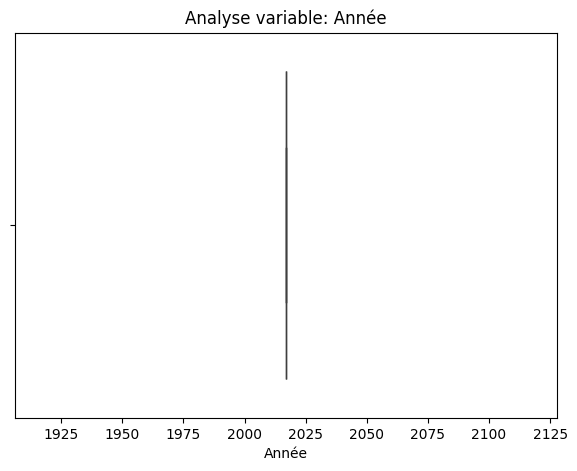

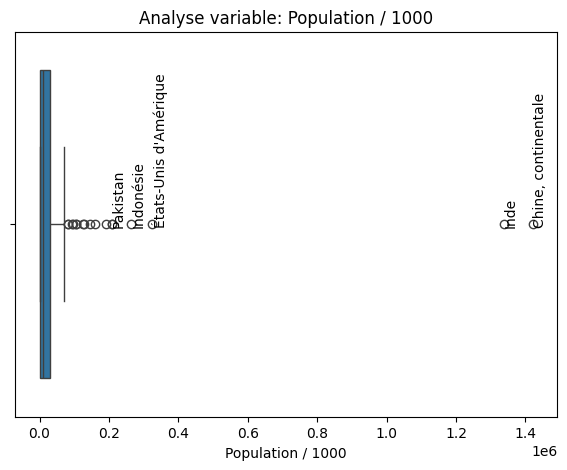

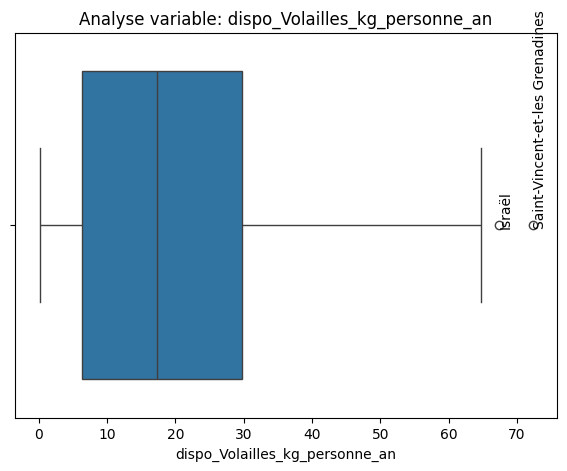

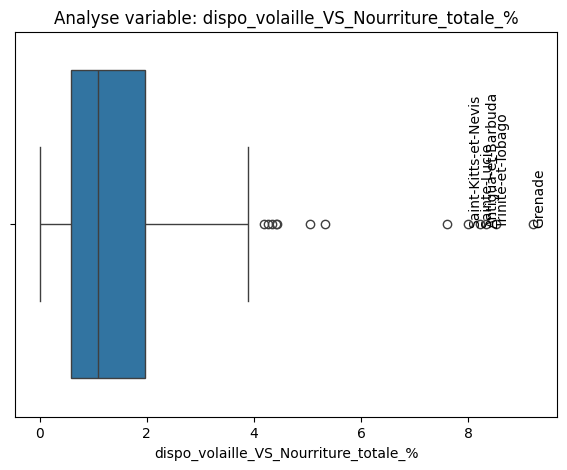

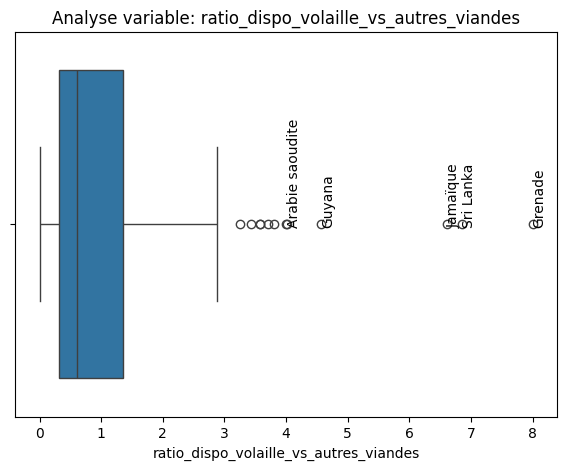

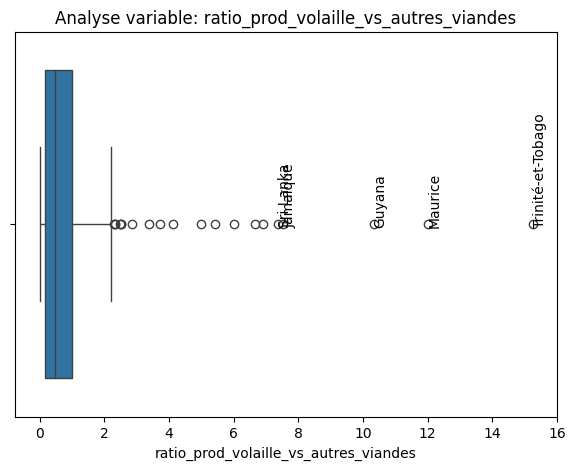

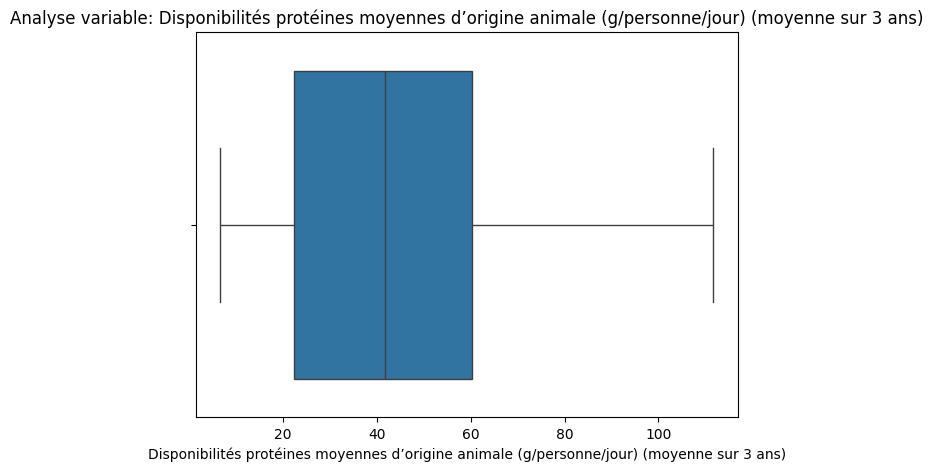

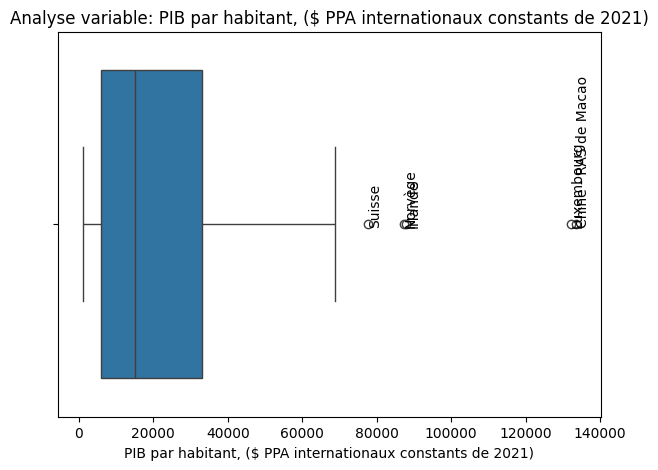

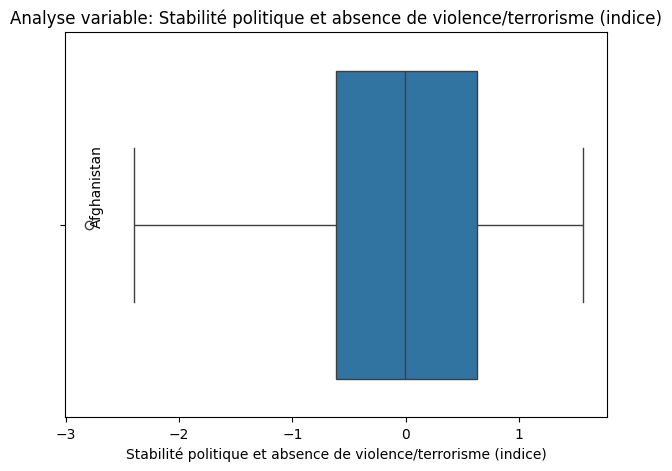

In [1210]:
#ANALYSE VARIABLES

num_cols = df_pays.select_dtypes(include=['number'])

for col in num_cols:
    plt.figure(figsize=(7,5))
    sns.boxplot(x=df_pays[col])
    plt.title(f"Analyse variable: {col}")

#OUTLIERS

    series = pd.to_numeric(df_pays[col], errors="coerce")
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    borne_min, borne_max = Q1 - 1.5*IQR, Q3 + 1.5*IQR

    outliers = df_pays[(series < borne_min) | (series > borne_max)][["Zone", col]]


    median = series.median()
    outliers["distance_from_median"] = abs(outliers[col] - median)

#SELECTION DE 5 MAX
    top_5_outliers = outliers.sort_values(by="distance_from_median", ascending=False).head(5)

    for _, row in top_5_outliers.iterrows():
        plt.text(row[col], 0, row["Zone"], rotation=90, fontsize=10)

    plt.show()



In [1211]:
#DROP OUTLIERS
df_pays = df_pays.drop(df_pays.loc[df_pays["Zone"] == "Chine, continentale"].index)
df_pays = df_pays.drop(df_pays.loc[df_pays["Zone"] == "Inde"].index)


In [1212]:
#VERIFICATION SUM DATA DISPO EN POPULATION >60% de LA POPULATION MONDIALE en 2017 et + DE 100 PAYS
pop_mondiale_2017 = df_population_initiale.loc[
    df_population_initiale["Année"] == 2017, "Population / 1000"
].sum()

pop_df_pays_2017 = df_pays.loc[
    df_pays["Année"] == 2017, "Population / 1000"
].sum()

part_pop = (pop_df_pays_2017 / pop_mondiale_2017) * 100
print("Part de la population couverte après retrait des outliers qui aider à monter à 94% de couverture mais en faussant les analyses:", part_pop, "%")

Part de la population couverte après retrait des outliers qui aider à monter à 94% de couverture mais en faussant les analyses: 58.104863833772505 %


In [1213]:
#Enlever année pour pas fausser l'analyse -> Le df est d'office etablis sur 2017
num_cols = num_cols.columns.drop('Année')
print(num_cols)

Index(['Population / 1000', 'dispo_Volailles_kg_personne_an',
       'dispo_volaille_VS_Nourriture_totale_%',
       'ratio_dispo_volaille_vs_autres_viandes',
       'ratio_prod_volaille_vs_autres_viandes',
       'Disponibilités protéines moyennes d’origine animale (g/personne/jour) (moyenne sur 3 ans)',
       'PIB par habitant, ($ PPA internationaux constants de 2021)',
       'Stabilité politique et absence de violence/terrorisme (indice)'],
      dtype='object')


In [1214]:
#STANDARDISATION avec scaller

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_pays[num_cols])
df_scaled = pd.DataFrame(df_scaled, columns=num_cols, index=df_pays.index)

print(df_scaled.head())


   Population / 1000  dispo_Volailles_kg_personne_an  \
0           0.182198                       -1.174673   
1           0.606945                        0.967595   
2          -0.502959                       -0.244642   
3           0.286637                       -0.870516   
4           1.132911                       -0.049606   

   dispo_volaille_VS_Nourriture_totale_%  \
0                              -0.744548   
1                               0.870527   
2                              -0.408798   
3                              -0.611406   
4                              -0.391431   

   ratio_dispo_volaille_vs_autres_viandes  \
0                               -0.688747   
1                                0.298830   
2                               -0.439347   
3                               -0.423373   
4                               -0.612009   

   ratio_prod_volaille_vs_autres_viandes  \
0                              -0.475941   
1                               0.01034

In [1215]:
df_scaled.to_csv('df_scaled.csv', index=False)

df_pays.to_csv('df_pays.csv', index=False)

